# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [1]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [2]:
df = pd.read_csv('cleaned_aviation_data.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70545 entries, 0 to 70544
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Event.Id                70545 non-null  object 
 1   Event.Date              70545 non-null  object 
 2   Make                    70545 non-null  object 
 3   Model                   70545 non-null  object 
 4   Aircraft.damage         70545 non-null  object 
 5   Injury.Severity         70545 non-null  object 
 6   Total.Fatal.Injuries    70545 non-null  float64
 7   Total.Serious.Injuries  70545 non-null  float64
 8   Total.Minor.Injuries    70545 non-null  float64
 9   Total.Uninjured         70545 non-null  float64
 10  Number.of.Engines       70545 non-null  float64
 11  Engine.Type             70545 non-null  object 
 12  Weather.Condition       70545 non-null  object 
 13  Broad.phase.of.flight   70545 non-null  object 
 14  Purpose.of.flight       70545 non-null

## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

In [3]:
# aircraft_size column (Large if occupants >= 20, else Small)
df["Aircraft_Size"] = np.where(df["Total_Occupants"] >= 20, "LARGE", "SMALL")
df["Aircraft_Size"].value_counts()

Aircraft_Size
SMALL    67982
LARGE     2563
Name: count, dtype: int64

#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

In [4]:
df['Fatal_Serious_Fraction'] = (df['Total.Serious.Injuries'] + df['Total.Fatal.Injuries'])/df['Total_Occupants']

In [5]:
size_stats_df = df.groupby(['Aircraft_Size', 'Make'])['Fatal_Serious_Fraction'].mean()
size_stats_df.sort_values().head(15)

Aircraft_Size  Make             
LARGE          AERO COMMANDER       0.000000
               SWEARINGEN           0.000000
               MOONEY               0.000000
               HUGHES               0.000000
               GULFSTREAM           0.000000
               SIKORSKY             0.000000
               CANADAIR             0.017705
               AEROSPATIALE         0.035119
               MCDONNELL DOUGLAS    0.036424
               LEARJET              0.043478
               BOMBARDIER           0.043844
               BOEING               0.057580
               AIRBUS               0.066849
               CESSNA               0.069383
               EMBRAER              0.072220
Name: Fatal_Serious_Fraction, dtype: float64

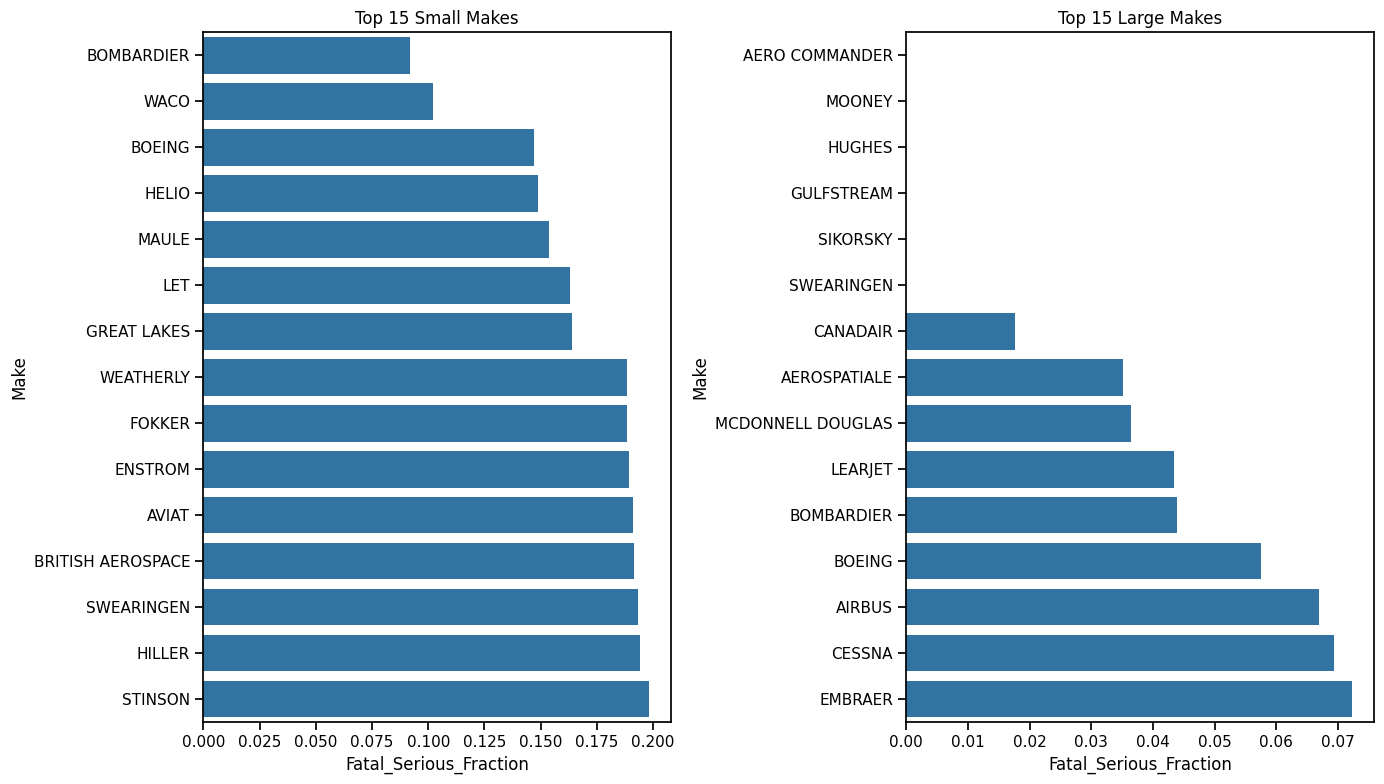

In [6]:

make_stats = (
    df.groupby(['Aircraft_Size', 'Make'])["Fatal_Serious_Fraction"].mean().reset_index()
)
low_risk_small = (
    make_stats[make_stats['Aircraft_Size'] == 'SMALL']
    .sort_values(by='Fatal_Serious_Fraction')
    .head(15)
)
low_risk_large = (
    make_stats[make_stats['Aircraft_Size'] == 'LARGE']
    .sort_values(by='Fatal_Serious_Fraction')
    .head(15))


sns.set_context("notebook")


fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# 3. Plot Small Makes (Left Plot - axes[0])
sns.barplot(
    data=low_risk_small,
    x="Fatal_Serious_Fraction",
    y="Make",
    ax=axes[0]
    
)
axes[0].set_title("Top 15 Small Makes")

# 4. Plot Large Makes (Right Plot - axes[1])
sns.barplot(
    data=low_risk_large,
    x="Fatal_Serious_Fraction",
    y="Make",
    ax=axes[1]
)
axes[1].set_title("Top 15 Large Makes")

plt.tight_layout()
plt.show()

**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

Text(0.5, 1.0, 'Mean of serious fatal injuries by Make for small planes(10 lowest)')

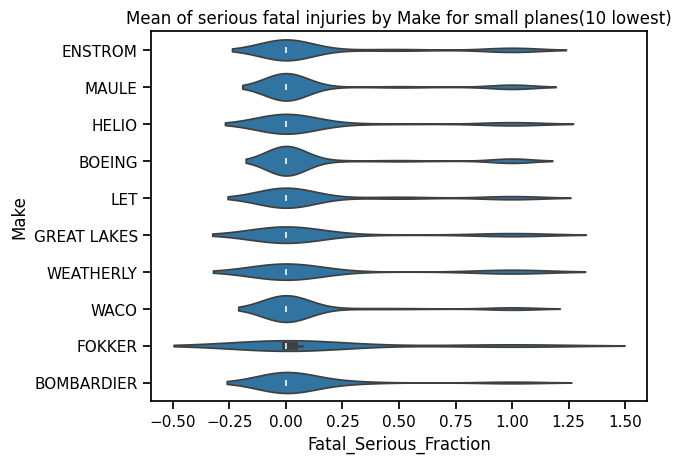

In [7]:

size_stats_df = size_stats_df.reset_index()

small = size_stats_df[size_stats_df["Aircraft_Size"] == "SMALL"]
small_stats = small.sort_values(by='Fatal_Serious_Fraction')
data = small_stats.head(10)
top_10_makes = small_stats.head(10)["Make"]
violin_data = df[(df["Aircraft_Size"] == "SMALL") & (df["Make"].isin(top_10_makes))]

sns.violinplot(data=violin_data, x='Fatal_Serious_Fraction', y='Make')
plt.title("Mean of serious fatal injuries by Make for small planes(10 lowest)")
#data

**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

Text(0.5, 1.0, 'Mean of serious fatal injuries by Make for large planes(10 lowest)')

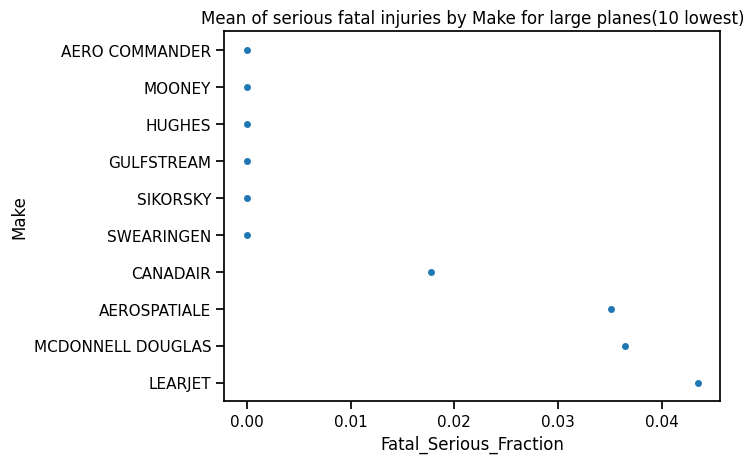

In [8]:
# Convert MultiIndex to columns
#size_stats_df = size_stats_df.reset_index()

# Now filter normally
large = size_stats_df[size_stats_df["Aircraft_Size"] == "LARGE"]
large_stats = large.sort_values(by='Fatal_Serious_Fraction')
large_data = large_stats.head(10)

sns.stripplot(data=large_data, y='Make', x='Fatal_Serious_Fraction')
plt.title("Mean of serious fatal injuries by Make for large planes(10 lowest)")
#large_data

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

In [9]:
planes_destruction = df.groupby(['Aircraft_Size', 'Make'])['Is_Destroyed'].mean().reset_index()
large_planes_destruction = planes_destruction[planes_destruction['Aircraft_Size']=='LARGE']
large_planes_destruction.sort_values(by='Is_Destroyed').head(15)

,Aircraft_Size,Make,Is_Destroyed
0,LARGE,AERO COMMANDER,0.000000
24,LARGE,RAYTHEON AIRCRAFT COMPANY,0.000000
22,LARGE,MOONEY,0.000000
18,LARGE,HUGHES,0.000000
17,LARGE,GULFSTREAM,0.000000
25,LARGE,SIKORSKY,0.000000
8,LARGE,CAMERON,0.000000
26,LARGE,SWEARINGEN,0.000000
1,LARGE,AEROSPATIALE,0.029412
6,LARGE,BOMBARDIER,0.035714


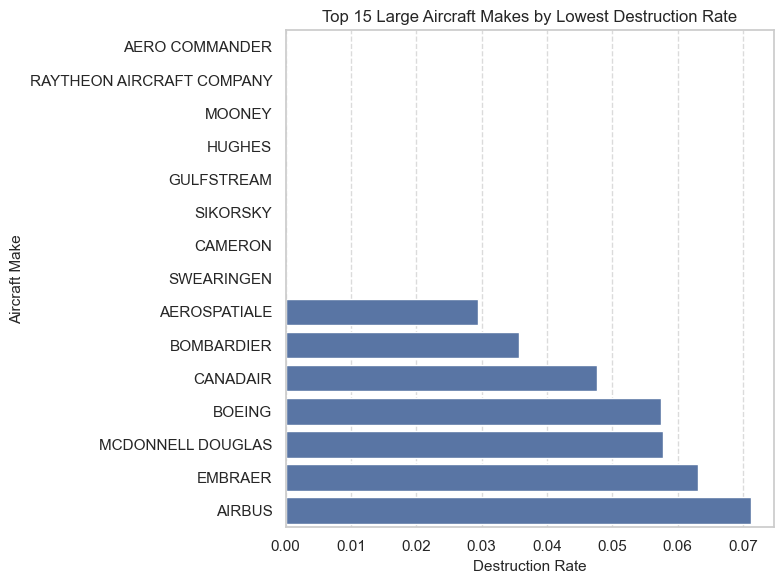

In [10]:
top_15_large = (
    planes_destruction[planes_destruction["Aircraft_Size"] == "LARGE"]
    .sort_values(by="Is_Destroyed", ascending=True)
    .head(15)
)

plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid")

# horizontal bar plot
sns.barplot(data=top_15_large, y="Make", x="Is_Destroyed")

plt.title(
    "Top 15 Large Aircraft Makes by Lowest Destruction Rate",
    fontsize=12,
)
plt.xlabel("Destruction Rate", fontsize=11)
plt.ylabel("Aircraft Make", fontsize=11)

plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

In [11]:
planes_destruction = df.groupby(['Aircraft_Size', 'Make'])['Is_Destroyed'].mean().reset_index()
small_planes_destruction = planes_destruction[planes_destruction['Aircraft_Size']=='SMALL']
small_planes_destruction.sort_values(by='Is_Destroyed').head(15)

,Aircraft_Size,Make,Is_Destroyed
33,SMALL,AIRBUS,0.033333
43,SMALL,BOMBARDIER,0.033333
35,SMALL,AMERICAN CHAMPION,0.037037
52,SMALL,DIAMOND,0.056911
42,SMALL,BOEING,0.061491
83,SMALL,RAVEN,0.063291
38,SMALL,BALLOON WORKS,0.064748
36,SMALL,AVIAT,0.069124
59,SMALL,FLIGHT DESIGN,0.075949
70,SMALL,LET,0.081481


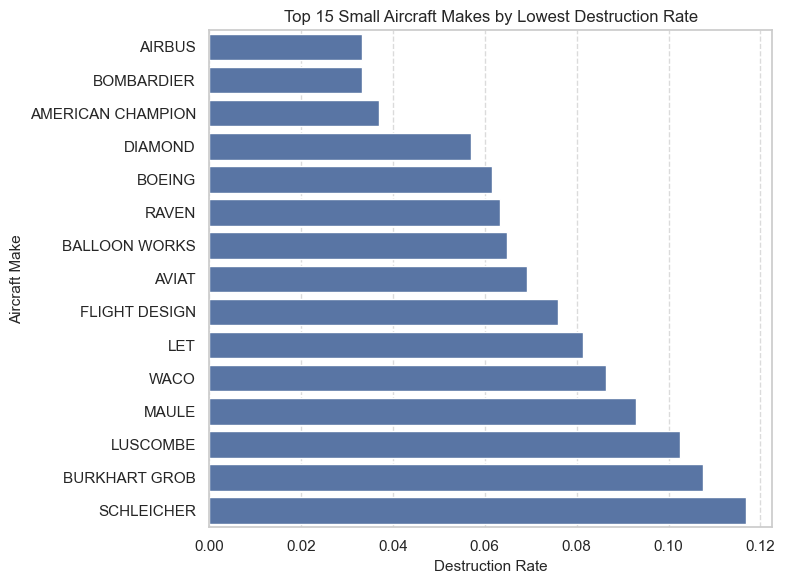

In [12]:

top_15_small = (
    planes_destruction[planes_destruction["Aircraft_Size"] == "SMALL"]
    .sort_values(by="Is_Destroyed", ascending=True)
    .head(15)
)

plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid")

# horizontal bar plot
sns.barplot(data=top_15_small, y="Make", x="Is_Destroyed")

plt.title(
    "Top 15 Small Aircraft Makes by Lowest Destruction Rate",
    fontsize=12,
)
plt.xlabel("Destruction Rate", fontsize=11)
plt.ylabel("Aircraft Make", fontsize=11)

plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

#### Injury Severity by Aircraft Size:
* Injury Severity by Aircraft Size: Large aircraft consistently demonstrate significantly lower fatal and serious injury rates than small aircraft. Within the top 10 lowest-risk large aircraft makes, 6 out of 10 achieved a 0.00 rate for severe passenger injuries, whereas even the lowest-risk small aircraft make recorded an injury fraction of approximately 0.09.
#### destruction rate
* Small aircraft experience a substantially higher rate of total destruction during incidents compared to large passenger jets. The structural vulnerability of smaller airframes during crashes directly accounts for their higher rate of fatal and serious occupant injuries.
#### Potential recommendation based off of the destroyed fraction and fraction fatally/seriously injured
* Primary Recommendation: Aero Commander, Mooney, Hughes, Gulfstream, and Sikorsky

Rationale: These manufacturers achieved a 0.00 total destruction rate and a 0.00 fatal/serious injury rate across recorded incidents, offering the highest level of hull preservation and passenger safety for commercial/larger operations.

* Primary Recommendation: Bombardier & Boeing

Rationale:

Bombardier: Demonstrates industry-leading safety metrics in the small aircraft segment, with an exceptionally low fatal/serious injury fraction of 0.009 and a total destruction rate of 0.033.

Boeing: Serves as a highly reliable secondary recommendation for smaller configuration builds, maintaining a fatal/serious injury fraction of 0.146 and a total destruction rate of 0.061.

### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

**Larger planes**

Text(0.5, 1.0, 'Mean of serious/fatal injuries for large plane types(make-model)')

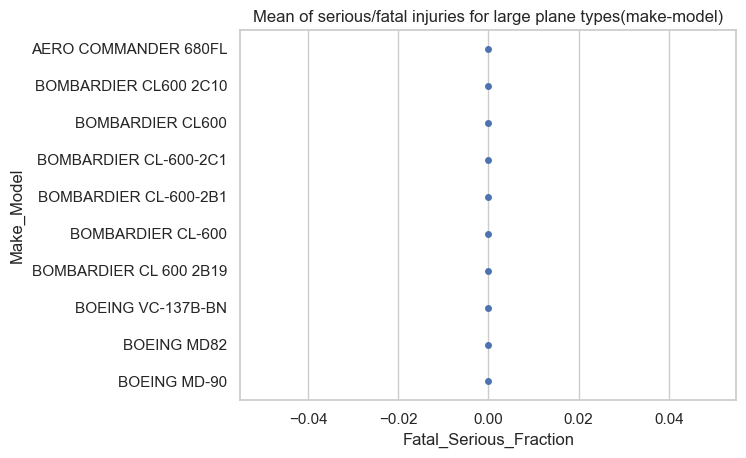

In [13]:
make_model_stats = df.groupby(['Aircraft_Size', 'Make_Model'])['Fatal_Serious_Fraction'].mean().reset_index()
make_model_stats

large_planes = make_model_stats[make_model_stats["Aircraft_Size"] == "LARGE"]
large_planes = large_planes.sort_values(by='Fatal_Serious_Fraction')
large_make_model = large_planes.head(10)
large_make_model

sns.stripplot(data=large_make_model, x='Fatal_Serious_Fraction', y='Make_Model')
plt.title("Mean of serious/fatal injuries for large plane types(make-model)")

**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

Text(0.5, 1.0, 'Mean of serious/ fatal injuries for small plane types(make-model)')

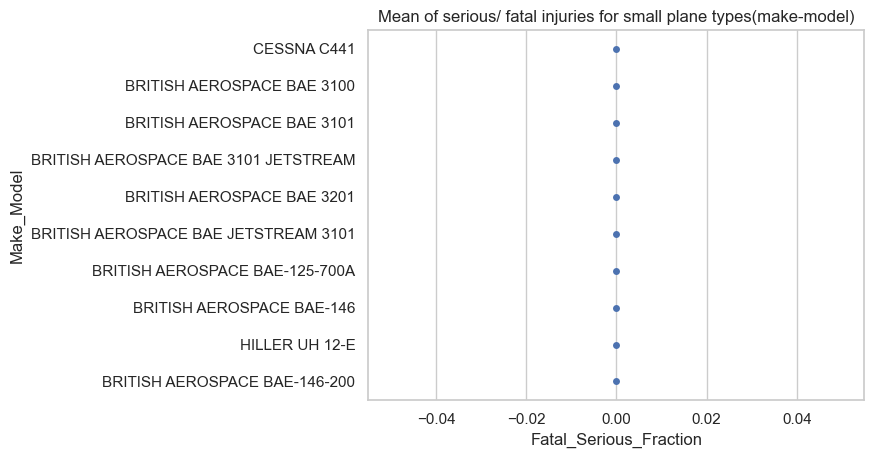

In [14]:
make_model_stats = df.groupby(['Aircraft_Size', 'Make_Model'])['Fatal_Serious_Fraction'].mean().reset_index()
make_model_stats

small_planes = make_model_stats[make_model_stats["Aircraft_Size"] == "SMALL"]
small_planes = small_planes.sort_values(by='Fatal_Serious_Fraction')
small_make_model = small_planes.head(10)
small_make_model

sns.stripplot(data=small_make_model, x='Fatal_Serious_Fraction', y='Make_Model')
plt.title("Mean of serious/ fatal injuries for small plane types(make-model)")

### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

In [15]:
x = df.groupby('Make')['Fatal_Serious_Fraction'].mean().reset_index()
x.sort_values(by='Fatal_Serious_Fraction').head(15)

,Make,Fatal_Serious_Fraction
16,BOMBARDIER,0.056496
6,AIRBUS,0.086138
15,BOEING,0.088494
69,WACO,0.101918
33,FOKKER,0.116997
48,MCDONNELL DOUGLAS,0.122421
38,HELIO,0.148728
46,MAULE,0.153889
43,LET,0.162963
35,GREAT LAKES,0.163793


- Large Planes (AERO COMMANDER / AERO COMMANDER 680FL):
Generally AERO COMMANDER wins in both injury and destruction rate  in large plane models with AERO COMMANDER 680FL being top Make-Model  with the lowest fatal/injury fraction.
* Small plane make-models  BRITISH AEROSPACE dominates and is stable in both large and small models

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.

#### Weather effect

In [16]:
weather_effect = df.groupby(['Weather.Condition', 'Aircraft.damage'])['Fatal_Serious_Fraction'].mean().reset_index()
weather_effect.sort_values(by='Fatal_Serious_Fraction', ascending=False)

,Weather.Condition,Aircraft.damage,Fatal_Serious_Fraction
0,IMC,DESTROYED,0.926828
4,UNKNOWN,DESTROYED,0.890708
8,VMC,DESTROYED,0.703347
6,UNKNOWN,SUBSTANTIAL,0.412808
2,IMC,SUBSTANTIAL,0.307313
7,UNKNOWN,UNKNOWN,0.165959
10,VMC,SUBSTANTIAL,0.130166
11,VMC,UNKNOWN,0.119480
9,VMC,MINOR,0.052220
3,IMC,UNKNOWN,0.047886


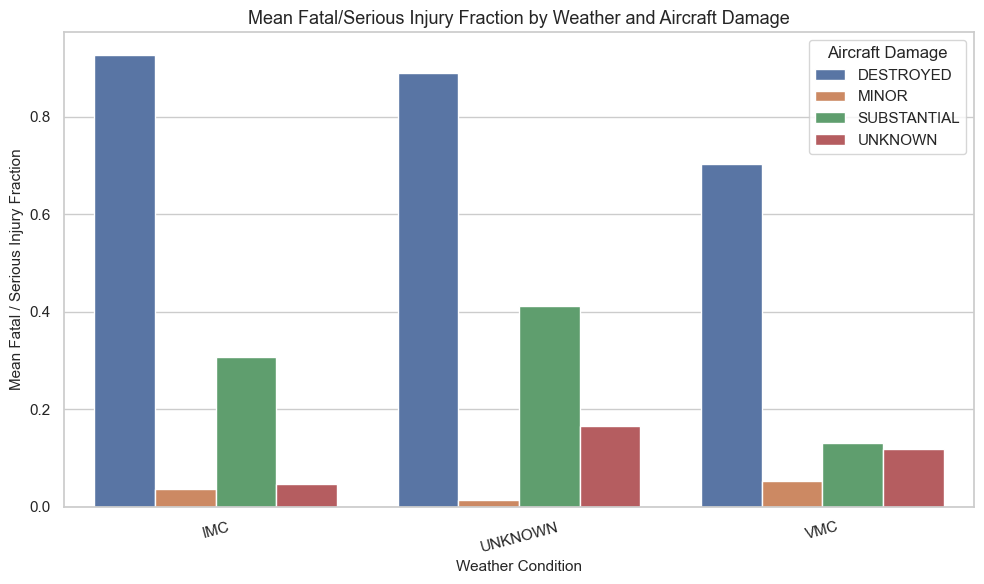

In [17]:
plt.figure(figsize=(10,6))
sns.barplot(data=weather_effect, x='Weather.Condition', y='Fatal_Serious_Fraction', hue='Aircraft.damage')
plt.title(
    "Mean Fatal/Serious Injury Fraction by Weather and Aircraft Damage",
    fontsize=13
)
plt.xlabel("Weather Condition", fontsize=11)
plt.ylabel("Mean Fatal / Serious Injury Fraction", fontsize=11)
plt.legend(title="Aircraft Damage")
plt.xticks(rotation=15)
plt.tight_layout()
#plt.grid(axis='y')
plt.show()


Accidents occurring in IMC have a drastically higher aircraft destruction rate compared to Visual Meteorological Conditions(VMC).
Such accidents also lead to higher fraction of serious/fatal injuries this is due to low visibility during such occassions

#### Engine type effect

In [18]:
type_effect = df.groupby(['Engine.Type', 'Aircraft.damage'])['Fatal_Serious_Fraction'].mean().reset_index()
type_effect.sort_values(by='Fatal_Serious_Fraction')
type_effect = type_effect[type_effect['Aircraft.damage'] == 'DESTROYED']
type_effect

,Engine.Type,Aircraft.damage,Fatal_Serious_Fraction
2,RECIPROCATING,DESTROYED,0.754064
6,TURBO FAN,DESTROYED,0.746158
10,TURBO JET,DESTROYED,0.840814
14,TURBO PROP,DESTROYED,0.805869
18,TURBO SHAFT,DESTROYED,0.695074
22,UNKNOWN,DESTROYED,0.858964


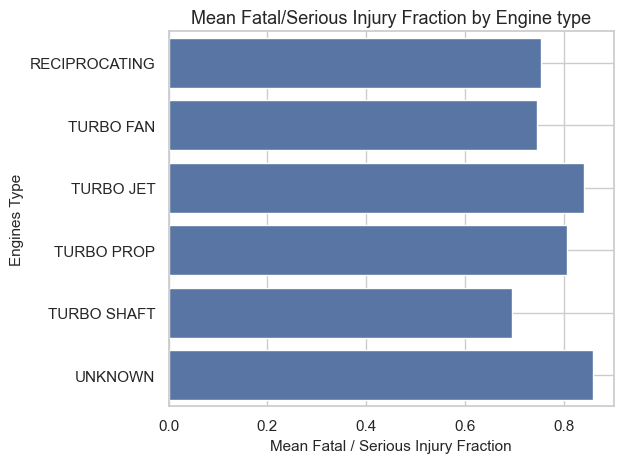

In [19]:
#plt.figure(figsize=(8,6))
sns.barplot(data=type_effect, y='Engine.Type', x='Fatal_Serious_Fraction')
plt.title(
    "Mean Fatal/Serious Injury Fraction by Engine type",
    fontsize=13,
)
plt.ylabel("Engines Type", fontsize=11)
plt.xlabel("Mean Fatal / Serious Injury Fraction", fontsize=11)
#plt.xticks(rotation=15)
plt.tight_layout()
plt.grid(axis='y')
plt.show()

Turbo Jet & Turbo Prop Risk: When a total destruction DESTROYED occurs, Turbo Jet (0.841) and Turbo Prop (0.806) aircraft carry higher fatal/serious injury fractions than Reciprocating piston engines (0.754) or Turbo Shaft  (0.695)

Baseline Survivability: Across all destroyed aircraft regardless of engine type, the severe injury rate remains high between 69.5% and 85.9%.